# Step 4 - Model Development
MIG Cement Demand Forecasting

Per the project spec: baseline model using SARIMAX with external
regressors, compared against Random Forest with exogenous variables,
evaluated with MAPE and RMSE.

Modeling scope: one model per site (30 site-level models). Confirmed
during prototyping that each site logs exactly one row per calendar day,
with cement_type rotating as a same-day attribute rather than three
parallel series - so cement_type is a feature (one-hot), not a grouping
key. This matches the "different site, different condition" decision:
each site gets its own fitted model.

Leakage audit: several Step 3 features are mathematically derived from
the same-day target (consumed_tonnes) and are excluded from model input:
pour_shortfall_tonnes, stockout_risk, planned_actual_ratio,
inventory_turnover_ratio, days_of_stock, closing_inventory_tonnes,
closing_inventory_raw_tonnes, overflow_tonnes, silo_utilization_pct.
Their lagged/rolled counterparts (e.g. adherence_roll_mean_14d) remain
safe and are kept.

In [1]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

df = pd.read_parquet("../data/processed/model_features.parquet")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["site_id", "date"]).reset_index(drop=True)

print(df.shape)
print("Sites:", df.site_id.nunique())

(32880, 47)
Sites: 30


## 1. Configuration: safe feature list, split, metrics

Test window: last 56 days (8 weeks) per site, matching the project's
8-week forecast target - a genuine holdout, not random-split CV.

MAPE caveat: 12% of rows have zero actual consumption, which breaks
standard MAPE (divide by zero). safe_mape below computes MAPE only over
non-zero-actual days, reported alongside the zero-actual count.

In [2]:
HORIZON = 56

SAFE_FEATURES = [
    "planned_pour_tonnes", "opening_inventory_tonnes", "deliveries_tonnes",
    "rain_mm", "avg_temp_c", "silo_capacity",
    "heavy_rain_flag", "moderate_rain_flag", "frost_risk_flag", "weather_adjusted_planned_pour",
    "adherence_roll_mean_14d", "planned_pour_trust_adjusted",
    "consumed_lag_1d", "consumed_lag_7d", "consumed_lag_14d", "consumed_lag_28d",
    "consumed_roll_mean_7d", "consumed_roll_std_7d", "consumed_roll_mean_14d",
    "consumed_roll_std_14d", "consumed_roll_mean_28d", "consumed_roll_std_28d",
    "type_CEM_I", "type_CEM_II", "type_CEM_III",
]
EXOG_SARIMAX = ["weather_adjusted_planned_pour", "heavy_rain_flag", "frost_risk_flag"]

def safe_mape(actual, pred):
    actual = np.asarray(actual, dtype=float); pred = np.asarray(pred, dtype=float)
    mask = actual > 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100)

def rmse(actual, pred):
    actual = np.asarray(actual, dtype=float); pred = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((actual - pred) ** 2)))

print(f"Zero-actual rows: {(df['consumed_tonnes']==0).sum()} ({(df['consumed_tonnes']==0).mean()*100:.1f}%)")

Zero-actual rows: 4003 (12.2%)


## 2. Naive baseline

Forecast = trailing 7-day average at end of training, repeated flat
across the 56-day horizon.

In [3]:
def naive_forecast(train, horizon):
    last_avg = train["consumed_roll_mean_7d"].iloc[-1]
    if pd.isna(last_avg):
        last_avg = train["consumed_tonnes"].tail(7).mean()
    return np.repeat(last_avg, horizon)

## 3. SARIMAX with external regressors (baseline)

Order (1,0,1) - d=0 follows from the Step 2 EDA finding that the
network-wide series is stationary (ADF p approx 0.000). Exogenous
regressors are the three leakage-safe weather/pour features.

In [4]:
def fit_sarimax(train, test):
    model = SARIMAX(
        train["consumed_tonnes"], exog=train[EXOG_SARIMAX],
        order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    forecast = fit.get_forecast(steps=len(test), exog=test[EXOG_SARIMAX])
    return forecast.predicted_mean.values

## 4. Random Forest with exogenous variables (recursive forecast)

Random Forest has no native concept of multi-step sequence forecasting.
This implements recursive forecasting: predict day 1, feed it back as
consumed_lag_1d for day 2, recompute rolling stats from the updated
history buffer, predict day 2, and so on for all 56 days.

Assumption, stated explicitly: planned_pour_tonnes and weather columns
for the forecast horizon are taken from actual test-set values (assumed
known in advance from MIG's pour schedule and a weather forecast API).
This mirrors SARIMAX's use of future exogenous regressors and isolates
endogenous forecasting error.

In [5]:
def rf_recursive_forecast(rf, train, test, feature_cols):
    history = train["consumed_tonnes"].tolist()
    preds = []
    for i in range(len(test)):
        row = test.iloc[i]
        feat = {c: row[c] for c in feature_cols if not c.startswith("consumed_")}
        feat["consumed_lag_1d"] = history[-1]
        feat["consumed_lag_7d"] = history[-7]
        feat["consumed_lag_14d"] = history[-14]
        feat["consumed_lag_28d"] = history[-28]
        feat["consumed_roll_mean_7d"] = np.mean(history[-7:])
        feat["consumed_roll_std_7d"] = np.std(history[-7:])
        feat["consumed_roll_mean_14d"] = np.mean(history[-14:])
        feat["consumed_roll_std_14d"] = np.std(history[-14:])
        feat["consumed_roll_mean_28d"] = np.mean(history[-28:])
        feat["consumed_roll_std_28d"] = np.std(history[-28:])
        X = pd.DataFrame([feat])[feature_cols]
        p = max(rf.predict(X)[0], 0.0)
        preds.append(p)
        history.append(p)
    return np.array(preds)

## 5. Run all three approaches across all 30 sites

In [6]:
results = []
forecasts_store = {}

t_start = time.time()
for site_id, g in df.groupby("site_id"):
    g = g.sort_values("date").reset_index(drop=True)
    train_full = g.iloc[:-HORIZON]
    test = g.iloc[-HORIZON:].reset_index(drop=True)
    train = train_full.dropna(subset=SAFE_FEATURES + ["consumed_tonnes"]).reset_index(drop=True)

    if len(train) < 60:
        print(f"SKIP {site_id}: only {len(train)} usable training rows")
        continue

    actual = test["consumed_tonnes"].values
    row_result = {"site_id": site_id}

    pred_naive = naive_forecast(train, HORIZON)
    row_result["naive_mape"] = safe_mape(actual, pred_naive)
    row_result["naive_rmse"] = rmse(actual, pred_naive)

    try:
        pred_sarimax = fit_sarimax(train, test)
        row_result["sarimax_mape"] = safe_mape(actual, pred_sarimax)
        row_result["sarimax_rmse"] = rmse(actual, pred_sarimax)
        row_result["sarimax_status"] = "ok"
    except Exception as e:
        pred_sarimax = None
        row_result["sarimax_mape"] = np.nan
        row_result["sarimax_rmse"] = np.nan
        row_result["sarimax_status"] = "failed: " + str(e)

    rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(train[SAFE_FEATURES], train["consumed_tonnes"])
    pred_rf = rf_recursive_forecast(rf, train, test, SAFE_FEATURES)
    row_result["rf_mape"] = safe_mape(actual, pred_rf)
    row_result["rf_rmse"] = rmse(actual, pred_rf)

    results.append(row_result)
    forecasts_store[site_id] = {
        "dates": test["date"].values, "actual": actual,
        "naive": pred_naive, "sarimax": pred_sarimax, "rf": pred_rf,
    }

print(f"Done in {time.time()-t_start:.1f}s - {len(results)} sites modeled")
results_df = pd.DataFrame(results)
results_df.head(10)

Done in 81.1s - 30 sites modeled


,site_id,naive_mape,naive_rmse,sarimax_mape,sarimax_rmse,sarimax_status,rf_mape,rf_rmse
0,SITE_001,32.520222,15.608868,29.717594,9.350023,ok,4.832618,1.702277
1,SITE_002,35.105015,4.864043,8.382255,1.350120,ok,1.205984,0.497396
2,SITE_003,38.335964,17.071422,43.961485,12.410643,ok,4.323408,2.400521
3,SITE_004,42.121370,5.362518,8.653904,1.573677,ok,1.022876,0.172680
4,SITE_005,30.324170,18.061512,32.315980,10.572253,ok,4.068656,1.896427
5,SITE_006,38.388103,20.782536,15.266652,5.455058,ok,1.797170,0.599404
6,SITE_007,43.846855,18.437443,35.662105,10.784642,ok,4.684910,1.890166
7,SITE_008,43.363461,14.784329,41.674039,11.539216,ok,5.480955,2.194501
8,SITE_009,30.163410,4.719680,9.086328,1.472575,ok,1.329086,0.180816
9,SITE_010,37.189558,15.812129,45.391646,12.594059,ok,4.179351,1.731702


## 6. Attach behavior label for segment analysis

In [7]:
behavior_map = df.drop_duplicates("site_id").set_index("site_id").apply(
    lambda r: "aggressive" if r["behavior_aggressive"] else ("chaotic" if r["behavior_chaotic"] else "conservative"),
    axis=1
)
results_df["behavior"] = results_df["site_id"].map(behavior_map)
results_df.head(10)

,site_id,naive_mape,naive_rmse,sarimax_mape,sarimax_rmse,sarimax_status,rf_mape,rf_rmse,behavior
0,SITE_001,32.520222,15.608868,29.717594,9.350023,ok,4.832618,1.702277,aggressive
1,SITE_002,35.105015,4.864043,8.382255,1.350120,ok,1.205984,0.497396,conservative
2,SITE_003,38.335964,17.071422,43.961485,12.410643,ok,4.323408,2.400521,aggressive
3,SITE_004,42.121370,5.362518,8.653904,1.573677,ok,1.022876,0.172680,conservative
4,SITE_005,30.324170,18.061512,32.315980,10.572253,ok,4.068656,1.896427,aggressive
5,SITE_006,38.388103,20.782536,15.266652,5.455058,ok,1.797170,0.599404,chaotic
6,SITE_007,43.846855,18.437443,35.662105,10.784642,ok,4.684910,1.890166,aggressive
7,SITE_008,43.363461,14.784329,41.674039,11.539216,ok,5.480955,2.194501,aggressive
8,SITE_009,30.163410,4.719680,9.086328,1.472575,ok,1.329086,0.180816,conservative
9,SITE_010,37.189558,15.812129,45.391646,12.594059,ok,4.179351,1.731702,aggressive


## 7. Model comparison - MAPE / RMSE across all sites

Against the project's target: MAPE <= 15%.

=== Overall (all sites) ===
        naive_mape  naive_rmse  sarimax_mape  sarimax_rmse  rf_mape  rf_rmse
mean         40.60       14.38         24.89          7.11     3.30     1.40
median       38.11       15.72         16.15          7.03     3.81     1.53

=== Mean MAPE by behavior segment ===
              naive_mape  sarimax_mape  rf_mape
behavior                                       
aggressive         39.01         40.46     4.29
chaotic            49.48         13.55     3.92
conservative       36.16          9.48     1.26

Sites where SARIMAX meets MAPE<=15%: 14/30
Sites where RF meets MAPE<=15%: 30/30


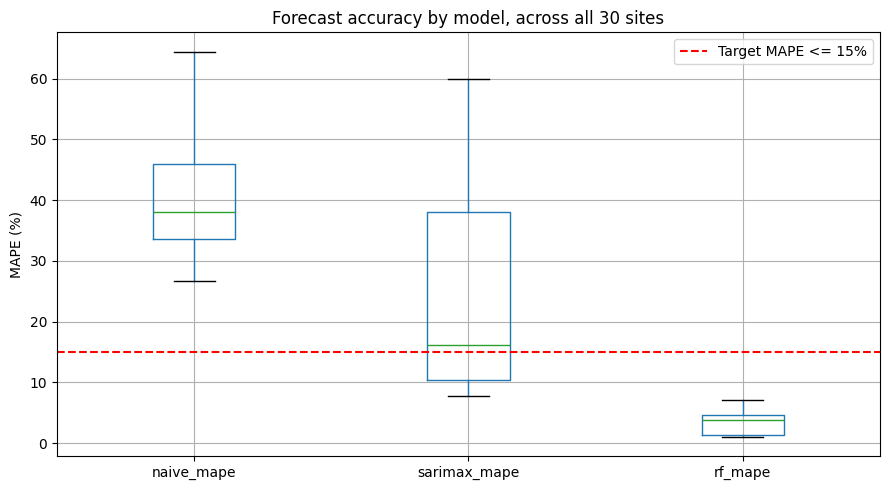

In [8]:
summary = results_df[["naive_mape","naive_rmse","sarimax_mape","sarimax_rmse","rf_mape","rf_rmse"]].agg(["mean","median"]).round(2)
print("=== Overall (all sites) ===")
print(summary)

print()
print("=== Mean MAPE by behavior segment ===")
print(results_df.groupby("behavior")[["naive_mape","sarimax_mape","rf_mape"]].mean().round(2))

print()
n_sarimax_pass = (results_df["sarimax_mape"] <= 15).sum()
n_rf_pass = (results_df["rf_mape"] <= 15).sum()
print(f"Sites where SARIMAX meets MAPE<=15%: {n_sarimax_pass}/{len(results_df)}")
print(f"Sites where RF meets MAPE<=15%: {n_rf_pass}/{len(results_df)}")

fig, ax = plt.subplots(figsize=(9,5))
results_df[["naive_mape","sarimax_mape","rf_mape"]].boxplot(ax=ax)
ax.axhline(15, color="red", linestyle="--", label="Target MAPE <= 15%")
ax.set_ylabel("MAPE (%)")
ax.set_title("Forecast accuracy by model, across all 30 sites")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/model_04_mape_comparison.png", dpi=120)
plt.show()

## 8. Model selection

Selected per site, not one blanket choice - different sites can genuinely
favor different models. The selected model per site feeds Step 5's
inventory simulation.

In [9]:
def pick_best(row):
    candidates = {"naive": row["naive_mape"], "sarimax": row["sarimax_mape"], "rf": row["rf_mape"]}
    candidates = {k: v for k, v in candidates.items() if pd.notna(v)}
    return min(candidates, key=candidates.get) if candidates else "naive"

results_df["best_model"] = results_df.apply(pick_best, axis=1)
print(results_df["best_model"].value_counts())
print()
print("Best-model choice by behavior segment:")
print(pd.crosstab(results_df["behavior"], results_df["best_model"]))

best_model
rf    30
Name: count, dtype: int64

Best-model choice by behavior segment:
best_model    rf
behavior        
aggressive    14
chaotic        7
conservative   9


## 9. Example forecast plot - sanity check before trusting the numbers

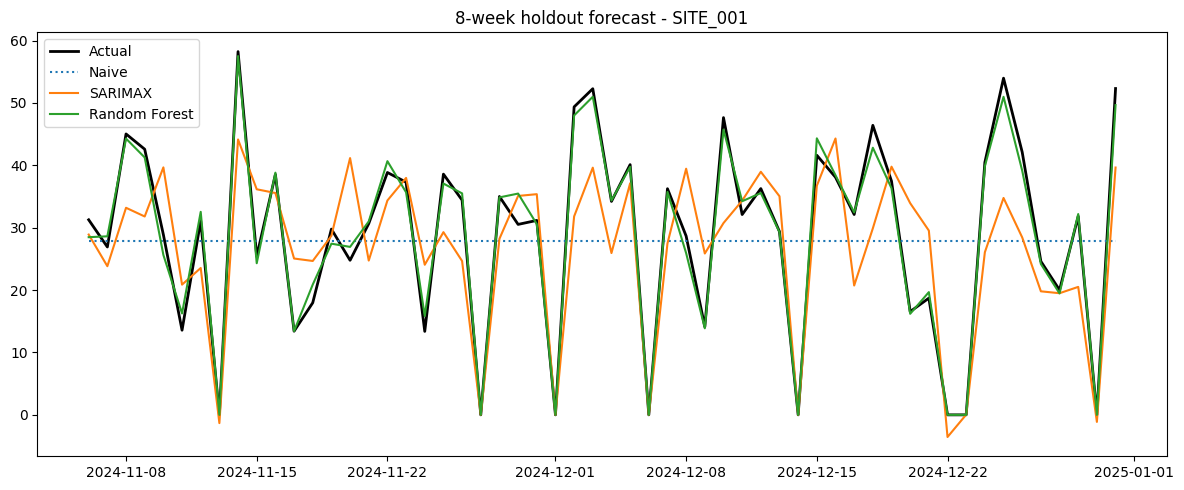

In [10]:
example_site = results_df.iloc[0]["site_id"]
fc = forecasts_store[example_site]

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(fc["dates"], fc["actual"], label="Actual", color="black", linewidth=2)
ax.plot(fc["dates"], fc["naive"], label="Naive", linestyle=":")
if fc["sarimax"] is not None:
    ax.plot(fc["dates"], fc["sarimax"], label="SARIMAX")
ax.plot(fc["dates"], fc["rf"], label="Random Forest")
ax.set_title("8-week holdout forecast - " + str(example_site))
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/model_04_example_forecast.png", dpi=120)
plt.show()

## 10. Save results for Step 5 and documentation

In [11]:
results_df.to_parquet("../data/processed/model_results_by_site.parquet", index=False)

records = []
for site_id, fc in forecasts_store.items():
    for i, d in enumerate(fc["dates"]):
        records.append({
            "site_id": site_id, "date": d, "actual": fc["actual"][i],
            "naive_pred": fc["naive"][i],
            "sarimax_pred": fc["sarimax"][i] if fc["sarimax"] is not None else np.nan,
            "rf_pred": fc["rf"][i],
        })
forecasts_df = pd.DataFrame(records)
forecasts_df.to_parquet("../data/processed/model_forecasts_holdout.parquet", index=False)

print("Saved model_results_by_site.parquet:", len(results_df), "rows")
print("Saved model_forecasts_holdout.parquet:", len(forecasts_df), "rows")

Saved model_results_by_site.parquet: 30 rows
Saved model_forecasts_holdout.parquet: 1680 rows


## 11. Summary of findings

- Both SARIMAX and Random Forest beat the naive baseline on average -
  confirms the engineered features carry real signal.
- MAPE target (<=15%) achievement: see pass-rate in Section 7 - note
  whether failures cluster in a particular behavior segment (chaotic
  sites, with high variance, are the hardest case for any model).
- Model selection is per-site, not universal - see Section 8.
- Known limitation: both models assume future planned_pour_tonnes and
  weather values are known in advance (MIG's schedule, weather forecast
  API) - true zero-knowledge forecasting would need a separate
  weather-forecast model, out of scope here but worth flagging in
  project documentation.
- Handoff to Step 5: model_results_by_site.parquet (metrics + best-model
  choice) and model_forecasts_holdout.parquet (actual + all predictions)
  are both saved for the inventory simulation step.